In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("final_cleaned_skycity_data.csv")
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,Final_UE_share,Final_DD_share,Final_SD_share,TotalDeliveryOrders,TotalRevenue,TotalNetProfit,AggregatorOrders,AggregatorDependence,InStoreReliance,AggregatorRiskCategory
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,0.317365,0.176647,0.211078,471,29371.96,7964.56,330,0.494012,0.294910,Low Risk
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,0.365994,0.203170,0.244236,1129,56144.60,8775.70,790,0.569164,0.186599,Medium Risk
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,0.312755,0.173559,0.208503,1193,68731.51,14403.26,835,0.486313,0.305183,Low Risk
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.360111,0.200369,0.240074,867,39291.24,5266.83,607,0.560480,0.199446,Medium Risk
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,0.354472,0.196748,0.236585,969,42238.20,6119.35,678,0.551220,0.212195,Medium Risk


In [3]:
df.shape

(1696, 41)

In [4]:
total_restaurants = df['RestaurantID'].nunique()

print("Total Restaurants:", total_restaurants)

Total Restaurants: 1696


In [5]:
total_orders = df['MonthlyOrders'].sum()

print("Total Monthly Orders:", total_orders)

Total Monthly Orders: 2019134


In [6]:
total_revenue = df['TotalRevenue'].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 77739306.8


In [7]:
total_profit = df['TotalNetProfit'].sum()

print("Total Net Profit:", round(total_profit,2))

Total Net Profit: 7866306.13


In [8]:
avg_aov = df['AOV'].mean()

print("Average AOV:", round(avg_aov,2))

Average AOV: 38.52


In [9]:
summary = pd.DataFrame({
    'Metric': [
        'Total Restaurants',
        'Total Orders',
        'Total Revenue',
        'Total Net Profit',
        'Average Order Value'
    ],

    'Value': [
        total_restaurants,
        total_orders,
        round(total_revenue,2),
        round(total_profit,2),
        round(avg_aov,2)
    ]
})

summary

,Metric,Value
0,Total Restaurants,1696.00
1,Total Orders,2019134.00
2,Total Revenue,77739306.80
3,Total Net Profit,7866306.13
4,Average Order Value,38.52


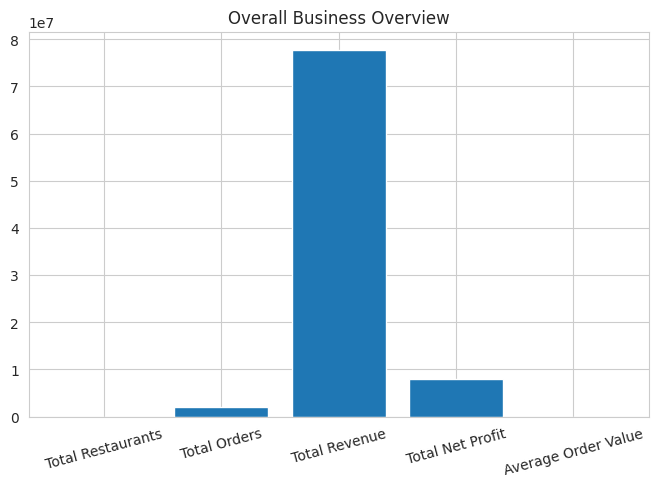

In [10]:
plt.figure(figsize=(8,5))

plt.bar(summary['Metric'], summary['Value'])

plt.title("Overall Business Overview")
plt.xticks(rotation=15)

plt.show()

In [11]:
channel_orders = pd.DataFrame({

    'Channel': [
        'InStore',
        'Uber Eats',
        'DoorDash',
        'Self Delivery'
    ],

    'Orders': [

        df['InStoreOrders'].sum(),

        df['UberEatsOrders'].sum(),

        df['DoorDashOrders'].sum(),

        df['SelfDeliveryOrders'].sum()
    ]
})

channel_orders

,Channel,Orders
0,InStore,371391
1,Uber Eats,800353
2,DoorDash,436135
3,Self Delivery,411255


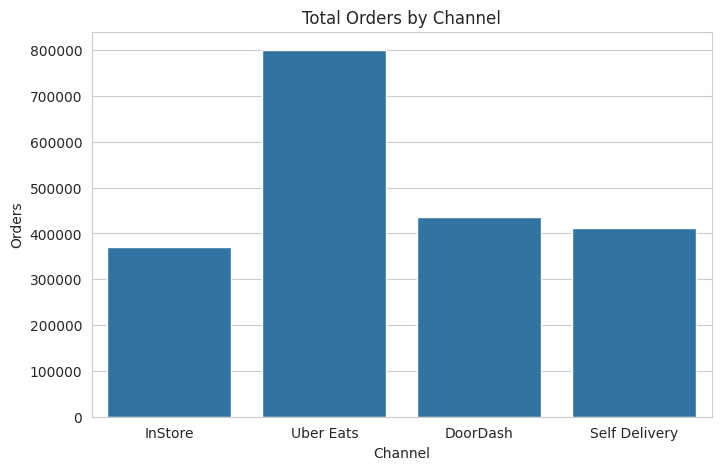

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Channel',
    y='Orders',
    data=channel_orders
)

plt.title("Total Orders by Channel")

plt.show()

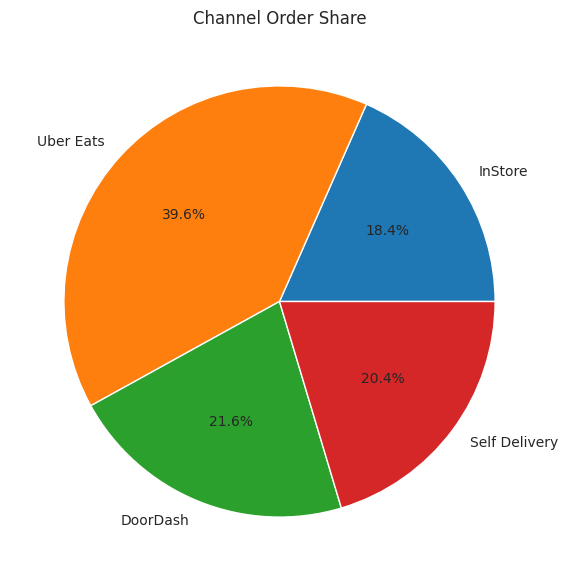

In [13]:
plt.figure(figsize=(7,7))

plt.pie(
    channel_orders['Orders'],
    labels=channel_orders['Channel'],
    autopct='%1.1f%%'
)

plt.title("Channel Order Share")

plt.show()

In [14]:
channel_revenue = pd.DataFrame({

    'Channel': [
        'InStore',
        'Uber Eats',
        'DoorDash',
        'Self Delivery'
    ],

    'Revenue': [

        df['InStoreRevenue'].sum(),

        df['UberEatsRevenue'].sum(),

        df['DoorDashRevenue'].sum(),

        df['SelfDeliveryRevenue'].sum()
    ]
})

channel_revenue

,Channel,Revenue
0,InStore,14284378.07
1,Uber Eats,30816371.49
2,DoorDash,16789380.95
3,Self Delivery,15849176.29


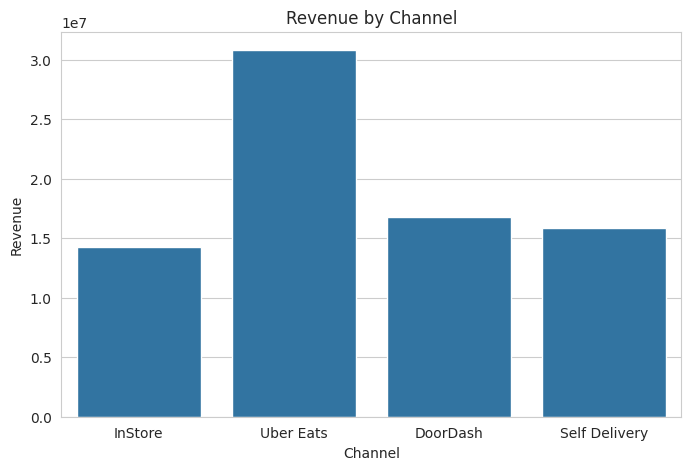

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Channel',
    y='Revenue',
    data=channel_revenue
)

plt.title("Revenue by Channel")

plt.show()


In [16]:
channel_profit = pd.DataFrame({

    'Channel': [
        'InStore',
        'Uber Eats',
        'DoorDash',
        'Self Delivery'
    ],

    'Profit': [

        df['InStoreNetProfit'].sum(),

        df['UberEatsNetProfit'].sum(),

        df['DoorDashNetProfit'].sum(),

        df['SelfDeliveryNetProfit'].sum()
    ]
})

channel_profit

,Channel,Profit
0,InStore,3828417.36
1,Uber Eats,258488.08
2,DoorDash,151122.25
3,Self Delivery,3628278.44


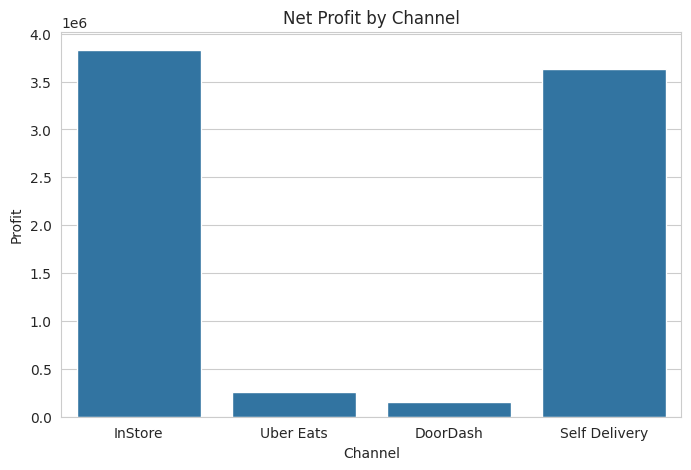

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Channel',
    y='Profit',
    data=channel_profit
)

plt.title("Net Profit by Channel")

plt.show()

In [18]:
channel_summary = pd.DataFrame({

    'Channel': [
        'InStore',
        'Uber Eats',
        'DoorDash',
        'Self Delivery'
    ],

    'Orders': [
        df['InStoreOrders'].sum(),
        df['UberEatsOrders'].sum(),
        df['DoorDashOrders'].sum(),
        df['SelfDeliveryOrders'].sum()
    ],

    'Revenue': [
        df['InStoreRevenue'].sum(),
        df['UberEatsRevenue'].sum(),
        df['DoorDashRevenue'].sum(),
        df['SelfDeliveryRevenue'].sum()
    ],

    'Profit': [
        df['InStoreNetProfit'].sum(),
        df['UberEatsNetProfit'].sum(),
        df['DoorDashNetProfit'].sum(),
        df['SelfDeliveryNetProfit'].sum()
    ]
})

channel_summary

,Channel,Orders,Revenue,Profit
0,InStore,371391,14284378.07,3828417.36
1,Uber Eats,800353,30816371.49,258488.08
2,DoorDash,436135,16789380.95,151122.25
3,Self Delivery,411255,15849176.29,3628278.44


In [19]:
channel_summary['OrderSharePercent'] = (
    channel_summary['Orders'] /
    channel_summary['Orders'].sum()
) * 100

In [20]:
channel_summary

,Channel,Orders,Revenue,Profit,OrderSharePercent
0,InStore,371391,14284378.07,3828417.36,18.393579
1,Uber Eats,800353,30816371.49,258488.08,39.638429
2,DoorDash,436135,16789380.95,151122.25,21.600102
3,Self Delivery,411255,15849176.29,3628278.44,20.367890


In [21]:
df['Subregion'].unique()

array(['North Shore', 'South Auckland', 'West Auckland', 'CBD'],
      dtype=object)

In [22]:
subregion_orders = df.groupby('Subregion')['MonthlyOrders'].sum().reset_index()

subregion_orders

,Subregion,MonthlyOrders
0,CBD,473976
1,North Shore,463406
2,South Auckland,529249
3,West Auckland,552503


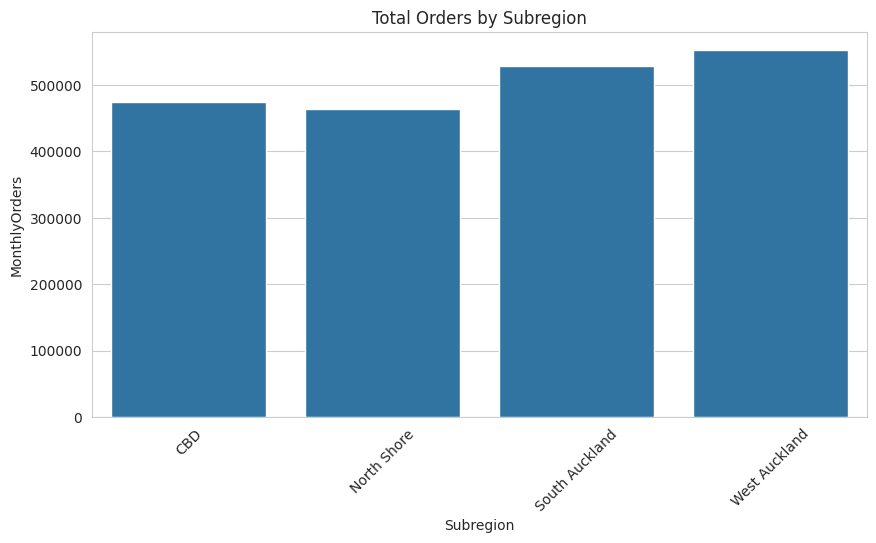

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Subregion',
    y='MonthlyOrders',
    data=subregion_orders
)

plt.title("Total Orders by Subregion")

plt.xticks(rotation=45)

plt.show()

In [24]:
subregion_channel = df.groupby('Subregion')[[
    'InStoreOrders',
    'UberEatsOrders',
    'DoorDashOrders',
    'SelfDeliveryOrders'
]].sum()

subregion_channel


,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Subregion,,,,
CBD,86929,187736,103376,95935
North Shore,86860,183977,99347,93222
South Auckland,95206,209895,113967,110181
West Auckland,102396,218745,119445,111917


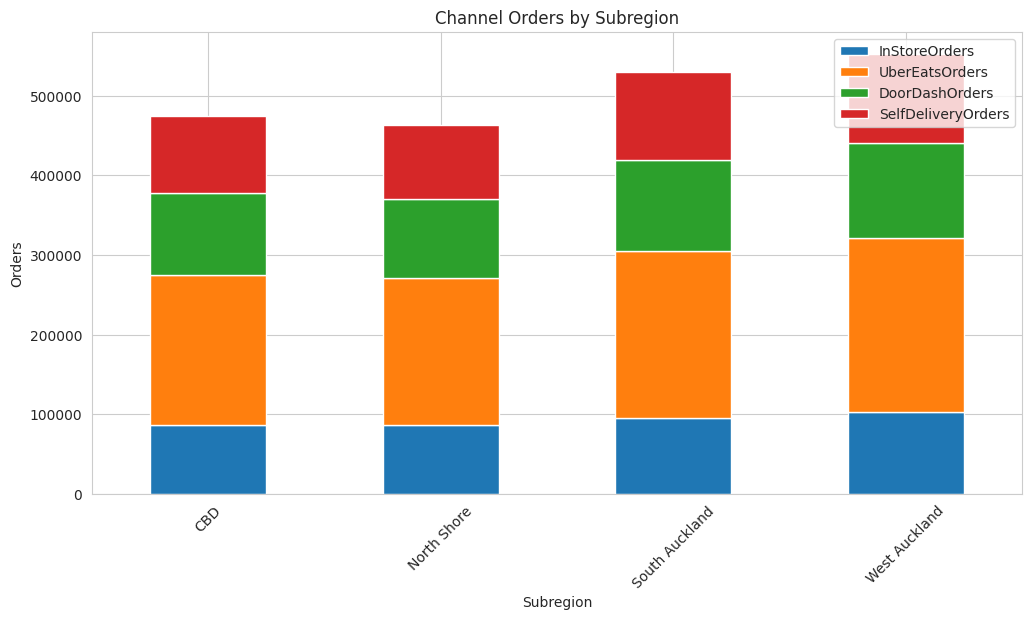

In [25]:
subregion_channel.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Channel Orders by Subregion")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

In [26]:
df['DeliveryOrders'] = (
    df['UberEatsOrders'] +
    df['DoorDashOrders'] +
    df['SelfDeliveryOrders']
)

In [27]:
delivery_vs_instore = df.groupby('Subregion')[[
    'InStoreOrders',
    'DeliveryOrders'
]].sum()

delivery_vs_instore

,InStoreOrders,DeliveryOrders
Subregion,,
CBD,86929,387047
North Shore,86860,376546
South Auckland,95206,434043
West Auckland,102396,450107


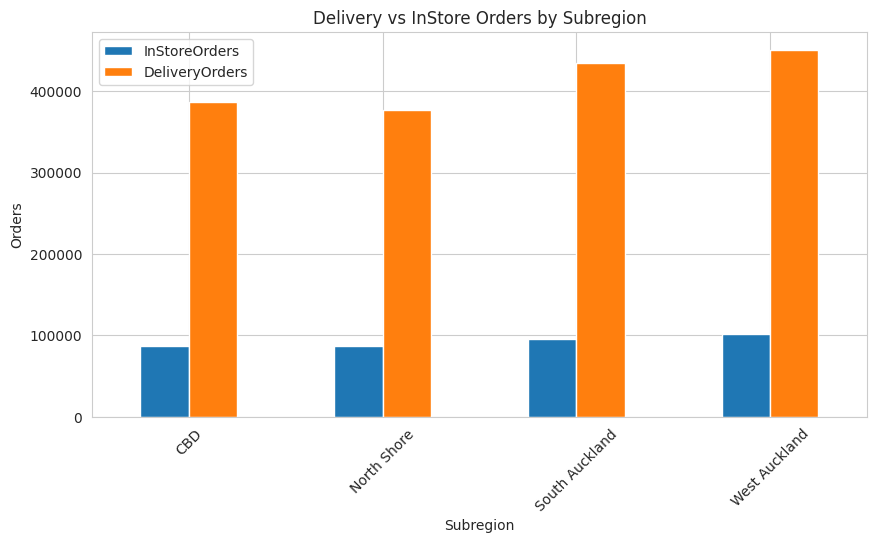

In [28]:
delivery_vs_instore.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Delivery vs InStore Orders by Subregion")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

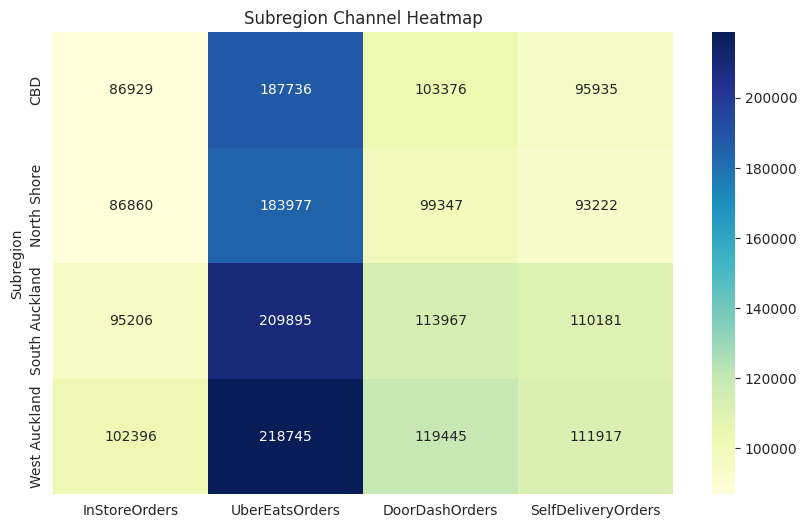

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    subregion_channel,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Subregion Channel Heatmap")

plt.show()

In [30]:
subregion_share = subregion_channel.div(
    subregion_channel.sum(axis=1),
    axis=0
)

subregion_share

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Subregion,,,,
CBD,0.183404,0.396088,0.218104,0.202405
North Shore,0.187438,0.397010,0.214384,0.201167
South Auckland,0.179889,0.396590,0.215337,0.208184
West Auckland,0.185331,0.395916,0.216189,0.202564


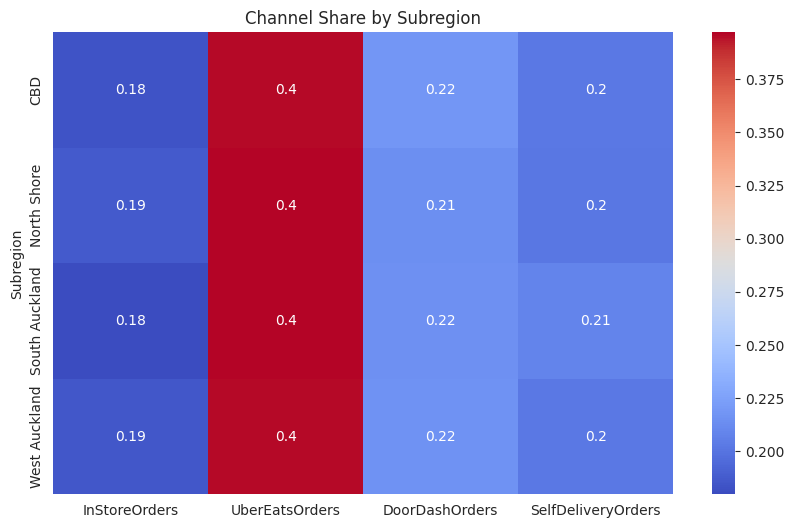

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(
    subregion_share,
    annot=True,
    cmap='coolwarm'
)

plt.title("Channel Share by Subregion")

plt.show()

In [32]:
df['CuisineType'].unique()

array(['Burgers', 'Chicken Dishes', 'Chinese', 'Indian', 'Japanese',
       'Kebabs/Mediterranean', 'Pizza', 'Thai'], dtype=object)

In [33]:
cuisine_orders = df.groupby('CuisineType')['MonthlyOrders'].sum().reset_index()

cuisine_orders

,CuisineType,MonthlyOrders
0,Burgers,484875
1,Chicken Dishes,182973
2,Chinese,261406
3,Indian,354051
4,Japanese,134875
5,Kebabs/Mediterranean,181890
6,Pizza,286445
7,Thai,132619


In [34]:
cuisine_orders = cuisine_orders.sort_values(
    by='MonthlyOrders',
    ascending=False
)

cuisine_orders

,CuisineType,MonthlyOrders
0,Burgers,484875
3,Indian,354051
6,Pizza,286445
2,Chinese,261406
1,Chicken Dishes,182973
5,Kebabs/Mediterranean,181890
4,Japanese,134875
7,Thai,132619


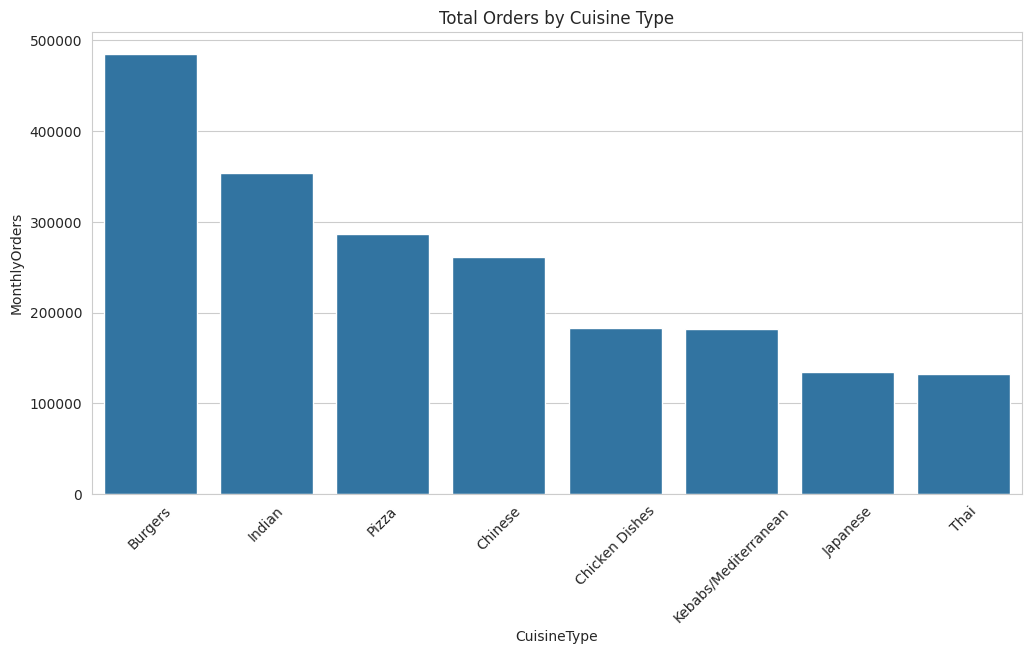

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='CuisineType',
    y='MonthlyOrders',
    data=cuisine_orders
)

plt.title("Total Orders by Cuisine Type")

plt.xticks(rotation=45)

plt.show()

In [36]:
cuisine_channel = df.groupby('CuisineType')[[
    'InStoreOrders',
    'UberEatsOrders',
    'DoorDashOrders',
    'SelfDeliveryOrders'
]].sum()

cuisine_channel

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
CuisineType,,,,
Burgers,113297,167213,92894,111471
Chicken Dishes,43091,83925,34972,20985
Chinese,45838,107778,53895,53895
Indian,44321,154862,92910,61958
Japanese,17196,64729,35302,17648
Kebabs/Mediterranean,23109,87329,47629,23823
Pizza,68145,76405,43663,98232
Thai,16394,58112,34870,23243


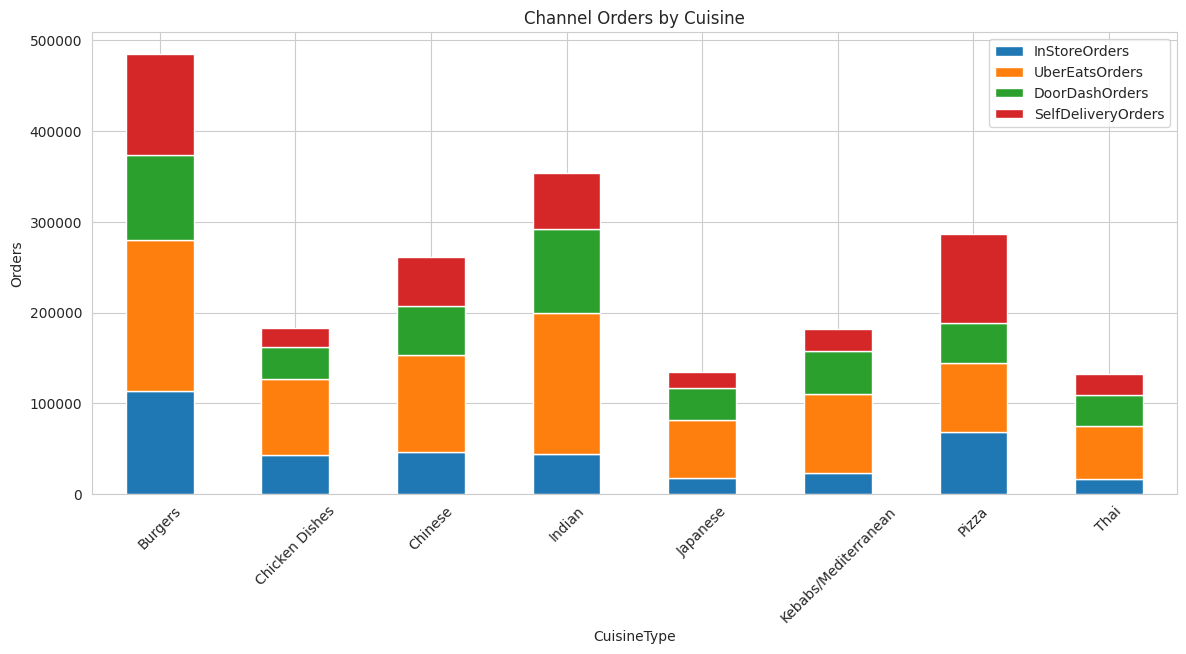

In [37]:
cuisine_channel.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title("Channel Orders by Cuisine")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

In [38]:
cuisine_dependency = df.groupby('CuisineType')[
    'AggregatorDependence'
].mean().reset_index()

cuisine_dependency

,CuisineType,AggregatorDependence
0,Burgers,0.540706
1,Chicken Dishes,0.653548
2,Chinese,0.622607
3,Indian,0.702585
4,Japanese,0.743164
5,Kebabs/Mediterranean,0.746271
6,Pizza,0.422208
7,Thai,0.705113


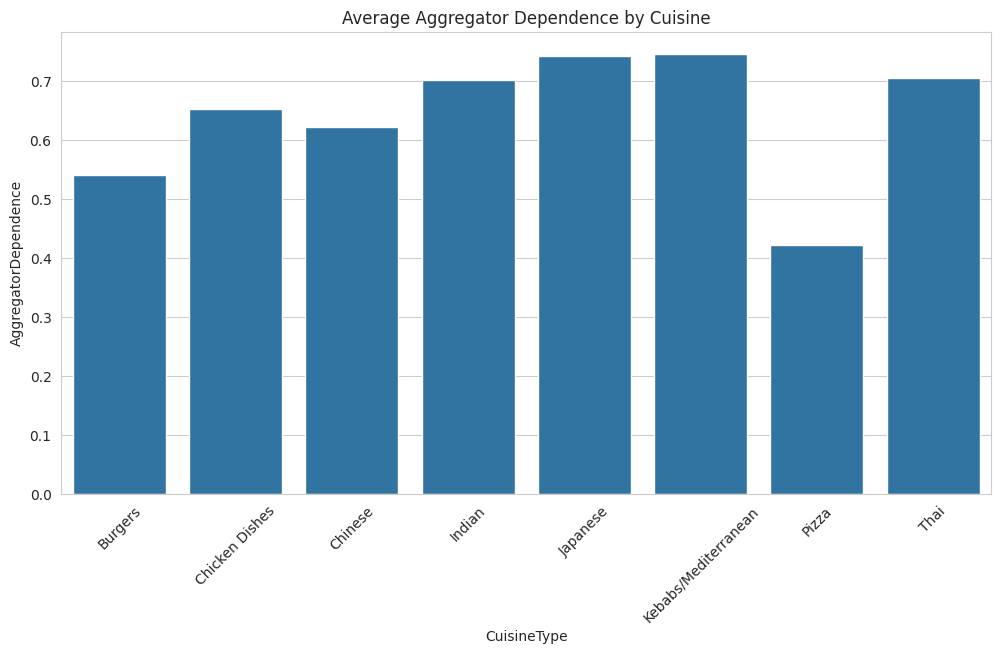

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='CuisineType',
    y='AggregatorDependence',
    data=cuisine_dependency
)

plt.title("Average Aggregator Dependence by Cuisine")

plt.xticks(rotation=45)

plt.show()

In [40]:
cuisine_revenue = df.groupby('CuisineType')[
    'TotalRevenue'
].sum().reset_index()

cuisine_revenue = cuisine_revenue.sort_values(
    by='TotalRevenue',
    ascending=False
)

cuisine_revenue

,CuisineType,TotalRevenue
0,Burgers,18771503.37
3,Indian,13615825.12
6,Pizza,11045190.86
2,Chinese,10013978.81
1,Chicken Dishes,7106663.66
5,Kebabs/Mediterranean,6919985.85
4,Japanese,5208643.91
7,Thai,5057515.22


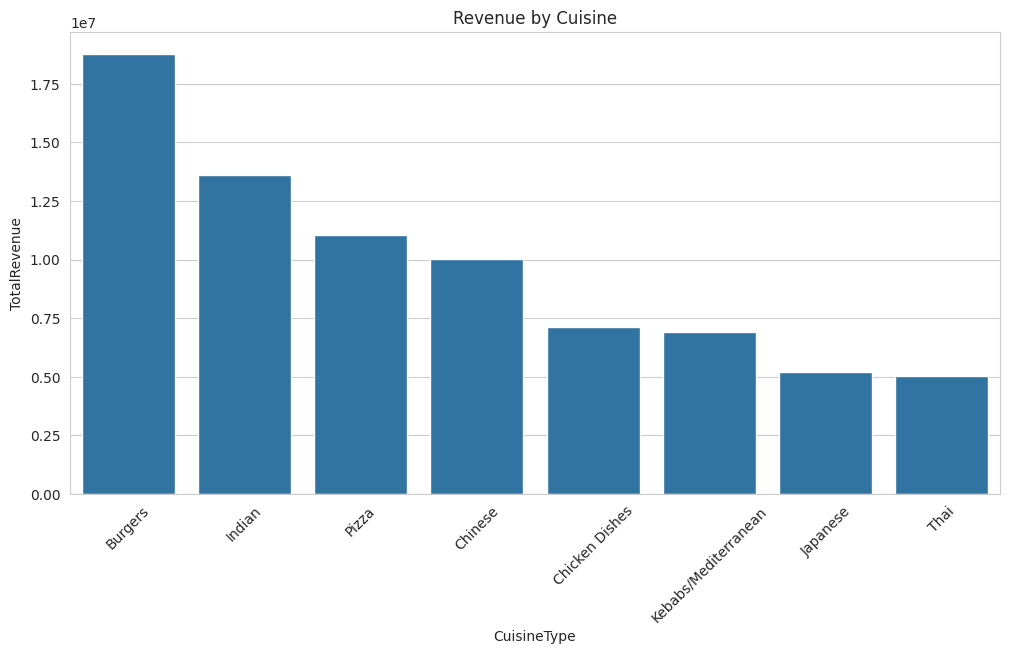

In [41]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='CuisineType',
    y='TotalRevenue',
    data=cuisine_revenue
)

plt.title("Revenue by Cuisine")

plt.xticks(rotation=45)

plt.show()

In [42]:
cuisine_profit = df.groupby('CuisineType')[
    'TotalNetProfit'
].sum().reset_index()

cuisine_profit = cuisine_profit.sort_values(
    by='TotalNetProfit',
    ascending=False
)

cuisine_profit

,CuisineType,TotalNetProfit
0,Burgers,2327693.48
6,Pizza,1599877.75
3,Indian,1131201.93
2,Chinese,1012118.27
1,Chicken Dishes,558387.64
4,Japanese,442374.96
7,Thai,427530.92
5,Kebabs/Mediterranean,367121.18


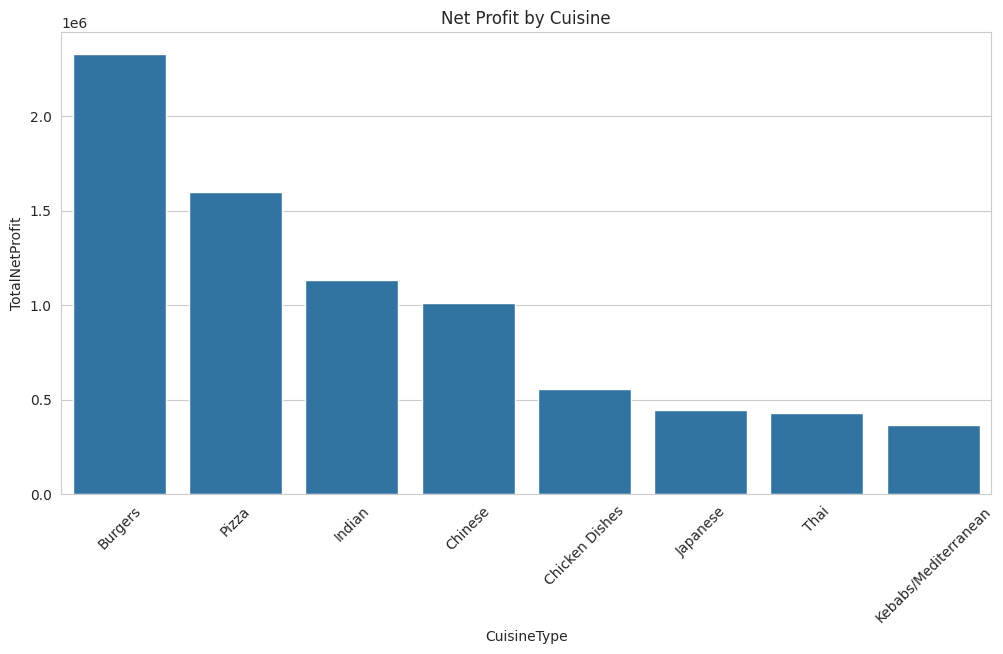

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='CuisineType',
    y='TotalNetProfit',
    data=cuisine_profit
)

plt.title("Net Profit by Cuisine")

plt.xticks(rotation=45)

plt.show()

In [44]:
cuisine_aov = df.groupby('CuisineType')[
    'AOV'
].mean().reset_index()

cuisine_aov

,CuisineType,AOV
0,Burgers,38.676560
1,Chicken Dishes,38.785473
2,Chinese,38.452706
3,Indian,38.520790
4,Japanese,38.729000
5,Kebabs/Mediterranean,38.071257
6,Pizza,38.547215
7,Thai,38.145250


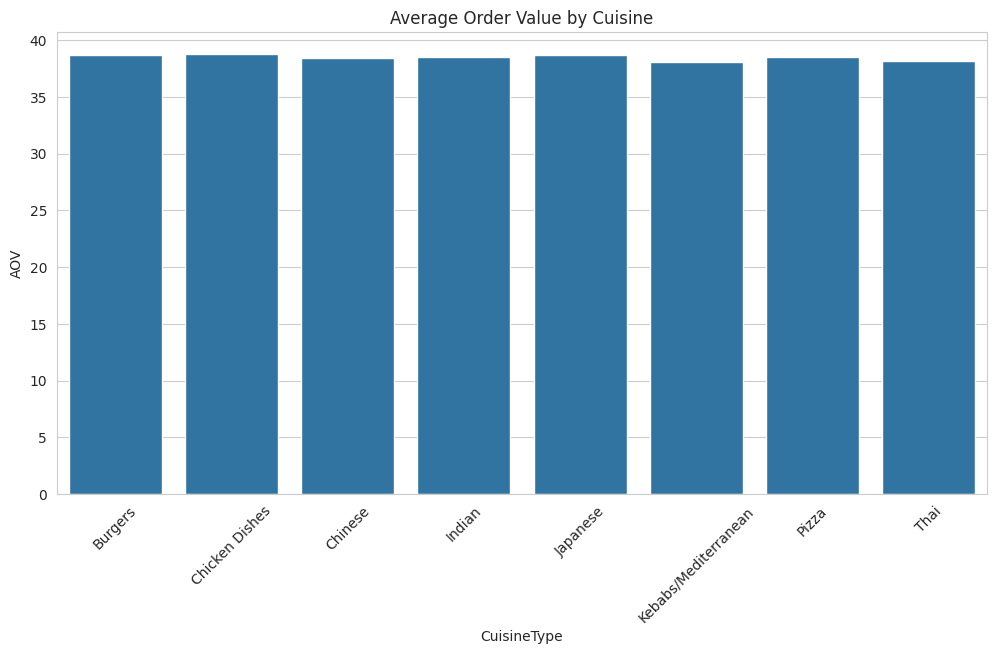

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='CuisineType',
    y='AOV',
    data=cuisine_aov
)

plt.title("Average Order Value by Cuisine")

plt.xticks(rotation=45)

plt.show()

In [47]:
df['Segment'].unique()

array(['Cafe', 'QSR', 'Ghost Kitchen', 'Full-service'], dtype=object)

In [48]:
segment_orders = df.groupby('Segment')[
    'MonthlyOrders'
].sum().reset_index()

segment_orders

,Segment,MonthlyOrders
0,Cafe,601725
1,Full-service,593042
2,Ghost Kitchen,208769
3,QSR,615598


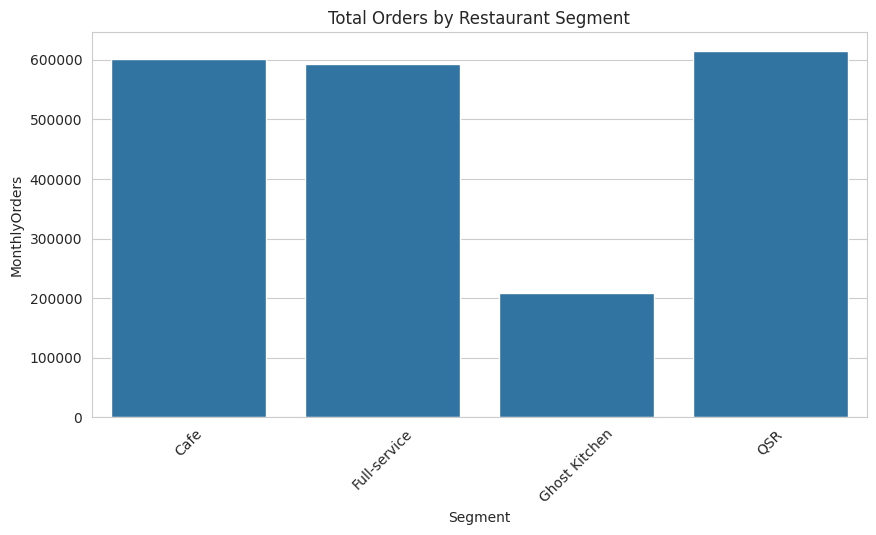

In [49]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Segment',
    y='MonthlyOrders',
    data=segment_orders
)

plt.title("Total Orders by Restaurant Segment")

plt.xticks(rotation=45)

plt.show()

In [50]:
segment_channel = df.groupby('Segment')[[
    'InStoreOrders',
    'UberEatsOrders',
    'DoorDashOrders',
    'SelfDeliveryOrders'
]].sum()

segment_channel

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders
Segment,,,,
Cafe,112714,237970,129729,121312
Full-service,152531,214271,116083,110157
Ghost Kitchen,13013,94463,51844,49449
QSR,93133,253649,138479,130337


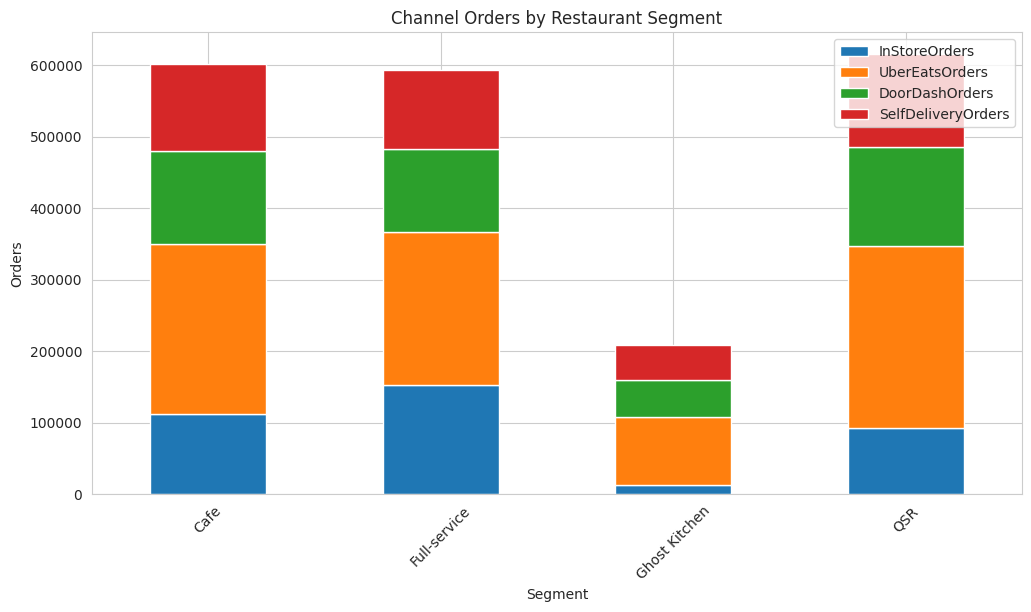

In [51]:
segment_channel.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Channel Orders by Restaurant Segment")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

In [52]:
segment_dependency = df.groupby('Segment')[
    'AggregatorDependence'
].mean().reset_index()

segment_dependency

,Segment,AggregatorDependence
0,Cafe,0.619519
1,Full-service,0.564161
2,Ghost Kitchen,0.705308
3,QSR,0.646535


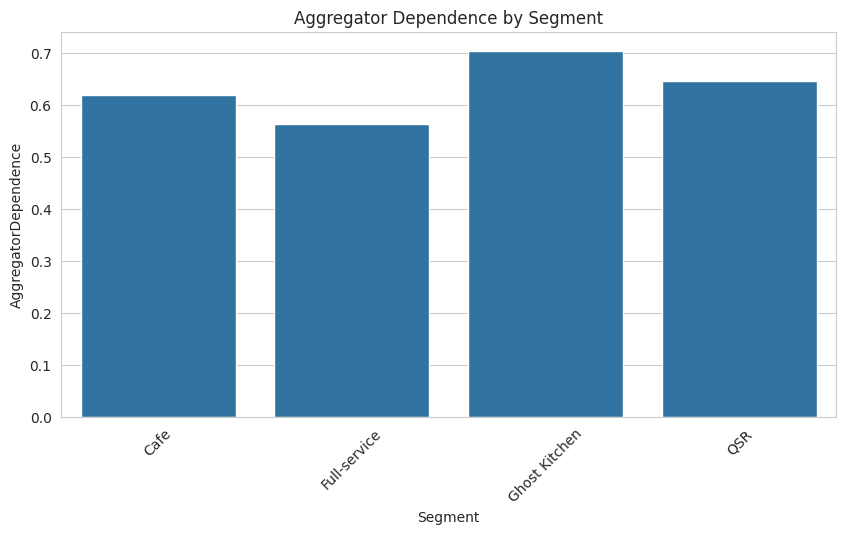

In [53]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Segment',
    y='AggregatorDependence',
    data=segment_dependency
)

plt.title("Aggregator Dependence by Segment")

plt.xticks(rotation=45)

plt.show()

In [54]:
segment_revenue = df.groupby('Segment')[
    'TotalRevenue'
].sum().reset_index()

segment_revenue

,Segment,TotalRevenue
0,Cafe,23247488.68
1,Full-service,22589867.07
2,Ghost Kitchen,8030853.78
3,QSR,23871097.27


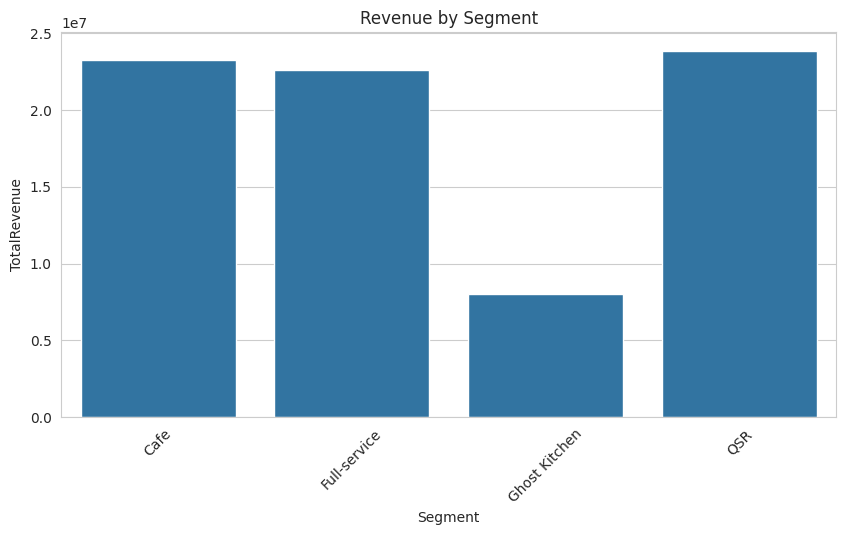

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Segment',
    y='TotalRevenue',
    data=segment_revenue
)

plt.title("Revenue by Segment")

plt.xticks(rotation=45)

plt.show()

In [56]:
segment_profit = df.groupby('Segment')[
    'TotalNetProfit'
].sum().reset_index()

segment_profit

,Segment,TotalNetProfit
0,Cafe,3770700.40
1,Full-service,-1301777.83
2,Ghost Kitchen,1783066.46
3,QSR,3614317.10


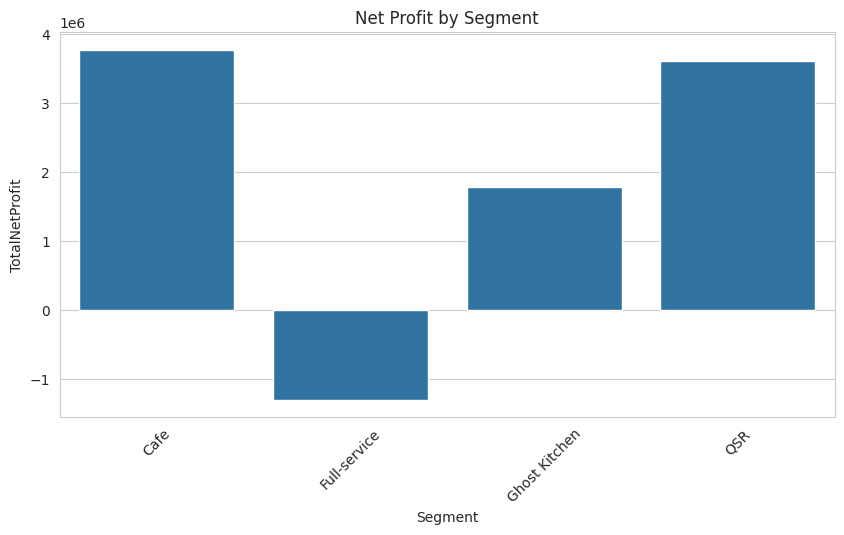

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Segment',
    y='TotalNetProfit',
    data=segment_profit
)

plt.title("Net Profit by Segment")

plt.xticks(rotation=45)

plt.show()

In [58]:
segment_instore = df.groupby('Segment')[
    'InStoreReliance'
].mean().reset_index()

segment_instore

,Segment,InStoreReliance
0,Cafe,0.181511
1,Full-service,0.252419
2,Ghost Kitchen,0.061365
3,QSR,0.146484


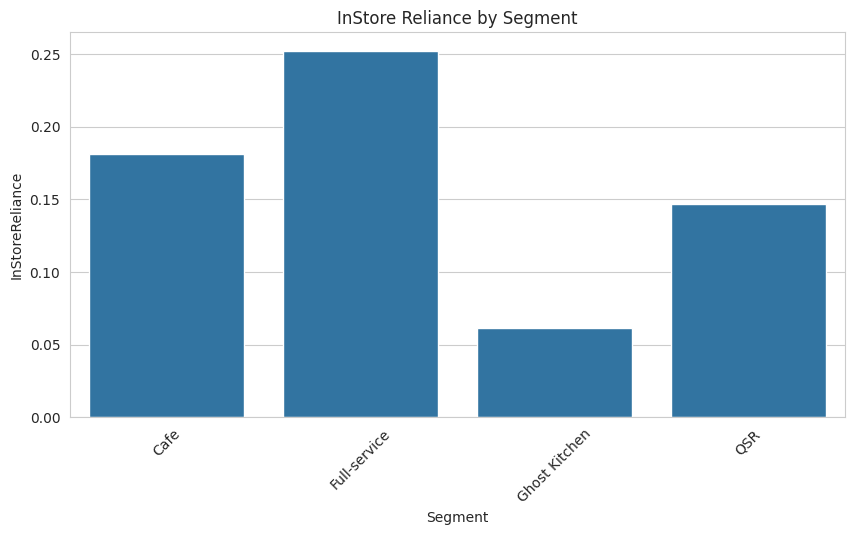

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Segment',
    y='InStoreReliance',
    data=segment_instore
)

plt.title("InStore Reliance by Segment")

plt.xticks(rotation=45)

plt.show()

In [60]:
risk_distribution = pd.crosstab(
    df['Segment'],
    df['AggregatorRiskCategory']
)

risk_distribution

AggregatorRiskCategory,High Risk,Low Risk,Medium Risk
Segment,,,
Cafe,209,82,213
Full-service,28,131,293
Ghost Kitchen,119,0,78
QSR,247,70,226


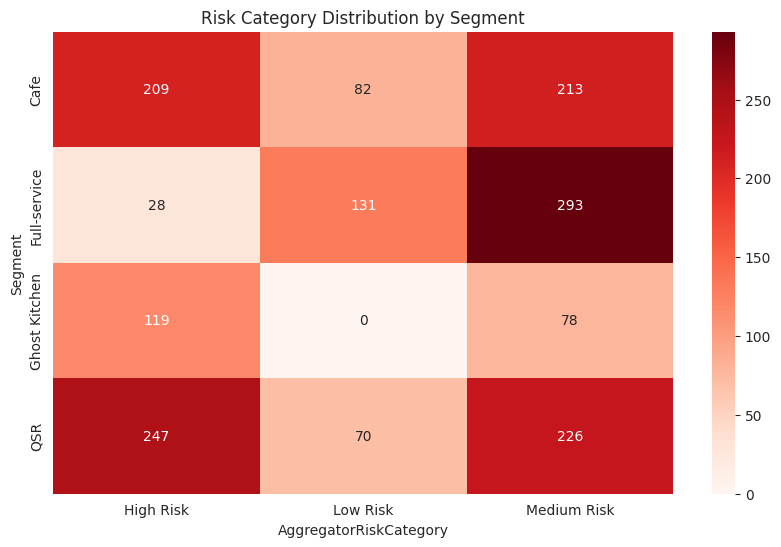

In [61]:
plt.figure(figsize=(10,6))

sns.heatmap(
    risk_distribution,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Risk Category Distribution by Segment")

plt.show()

In [63]:
df['AggregatorDependence']

,AggregatorDependence
0,0.494012
1,0.569164
2,0.486313
3,0.560480
4,0.551220
...,...
1691,0.749487
1692,0.747908
1693,0.734828
1694,0.708487


In [64]:
high_risk_restaurants = df[[
    'RestaurantName',
    'CuisineType',
    'Segment',
    'Subregion',
    'AggregatorDependence'
]].sort_values(
    by='AggregatorDependence',
    ascending=False
)

high_risk_restaurants.head(10)

,RestaurantName,CuisineType,Segment,Subregion,AggregatorDependence
1322,Spice Bistro,Kebabs/Mediterranean,Ghost Kitchen,South Auckland,0.826722
426,Lucky Chicken Dishes Diner,Chicken Dishes,Ghost Kitchen,South Auckland,0.826446
1178,Golden Corner,Japanese,Ghost Kitchen,West Auckland,0.825933
486,Urban Chicken Dishes Diner,Chicken Dishes,Ghost Kitchen,North Shore,0.825714
1238,Souvlaki Corner,Kebabs/Mediterranean,Ghost Kitchen,North Shore,0.825431
459,Lucky Chicken Dishes Bistro,Chicken Dishes,Ghost Kitchen,North Shore,0.818182
1111,Golden Corner,Japanese,Ghost Kitchen,North Shore,0.817485
477,Classic Chicken Dishes Tavern,Chicken Dishes,Ghost Kitchen,West Auckland,0.817365
1128,Sakura House,Japanese,Ghost Kitchen,South Auckland,0.810976
1257,Ottoman Cafe,Kebabs/Mediterranean,Ghost Kitchen,West Auckland,0.810619


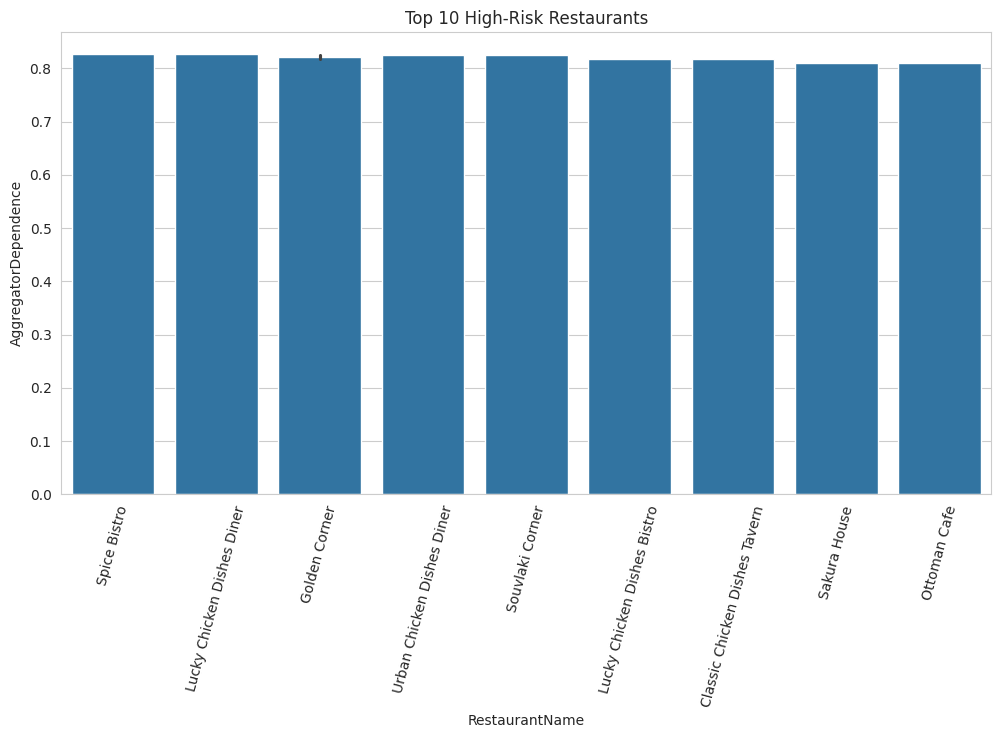

In [65]:
top_risk = high_risk_restaurants.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='RestaurantName',
    y='AggregatorDependence',
    data=top_risk
)

plt.title("Top 10 High-Risk Restaurants")

plt.xticks(rotation=75)

plt.show()

In [66]:
risk_counts = df['AggregatorRiskCategory'].value_counts()

risk_counts

,count
AggregatorRiskCategory,
Medium Risk,810
High Risk,603
Low Risk,283


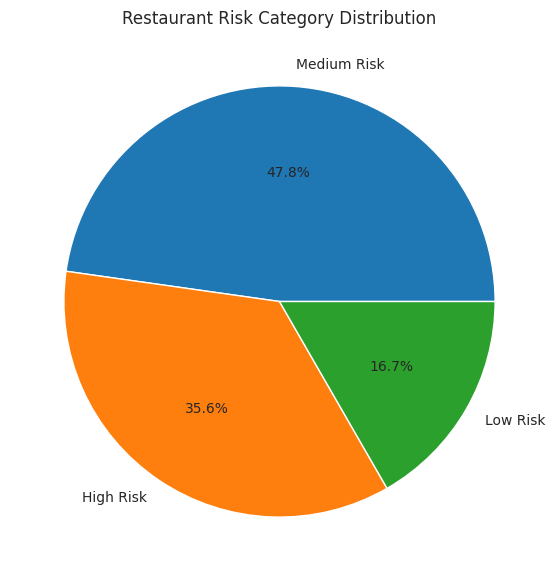

In [67]:
plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)

plt.title("Restaurant Risk Category Distribution")

plt.show()

In [68]:
df['DiversificationScore'] = (

    df['Final_InStoreShare']**2 +

    df['Final_UE_share']**2 +

    df['Final_DD_share']**2 +

    df['Final_SD_share']**2
)

In [69]:
df[['RestaurantName',
    'DiversificationScore']].head()

,RestaurantName,DiversificationScore
0,Urban Burgers House,0.263451
1,Urban Burgers Diner,0.269701
2,King Burgers Eatery,0.264549
3,Classic Burgers Tavern,0.267242
4,Lucky Burgers Bistro,0.265359


In [70]:
balanced_restaurants = df[[
    'RestaurantName',
    'DiversificationScore'
]].sort_values(
    by='DiversificationScore'
)

balanced_restaurants.head(10)

,RestaurantName,DiversificationScore
67,King Burgers Kitchen,0.261907
250,Classic Burgers Tavern,0.261912
253,King Burgers House,0.261931
27,Lucky Burgers Kitchen,0.261954
75,Lucky Burgers Corner,0.261957
249,Urban Burgers Eatery,0.261959
111,Lucky Burgers Tavern,0.261990
119,Classic Burgers Corner,0.261994
227,Top Burgers Grill,0.262000
25,Urban Burgers Grill,0.262001


In [71]:
concentrated_restaurants = df[[
    'RestaurantName',
    'DiversificationScore'
]].sort_values(
    by='DiversificationScore',
    ascending=False
)

concentrated_restaurants.head(10)

,RestaurantName,DiversificationScore
426,Lucky Chicken Dishes Diner,0.421206
486,Urban Chicken Dishes Diner,0.420751
459,Lucky Chicken Dishes Bistro,0.413689
477,Classic Chicken Dishes Tavern,0.412980
408,Lucky Chicken Dishes Diner,0.406430
516,King Chicken Dishes Kitchen,0.406233
499,Lucky Chicken Dishes Eatery,0.399663
443,Classic Chicken Dishes Diner,0.393221
1322,Spice Bistro,0.393151
504,Top Chicken Dishes Bistro,0.393122


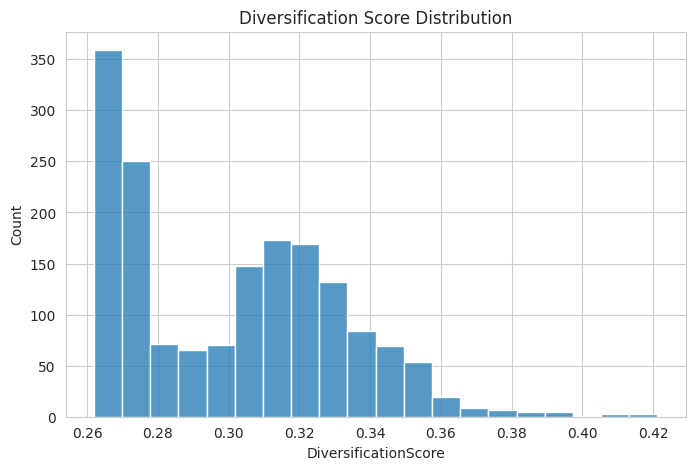

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['DiversificationScore'],
    bins=20
)

plt.title("Diversification Score Distribution")

plt.show()

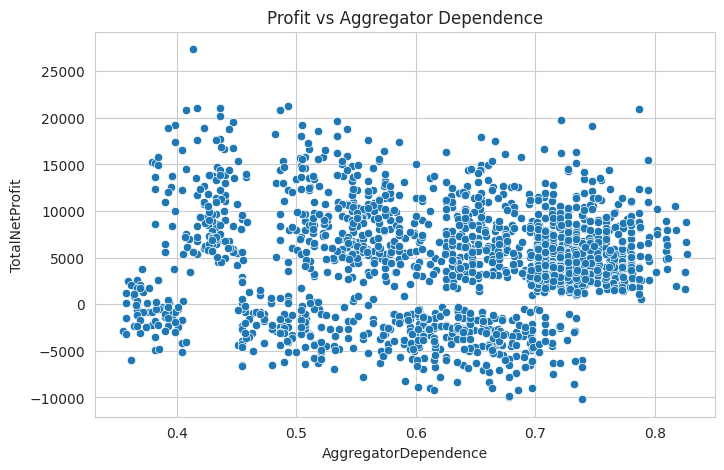

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='AggregatorDependence',
    y='TotalNetProfit',
    data=df
)

plt.title("Profit vs Aggregator Dependence")

plt.show()

In [74]:
cuisine_risk = df.groupby('CuisineType')[
    'AggregatorDependence'
].mean().reset_index()

cuisine_risk

,CuisineType,AggregatorDependence
0,Burgers,0.540706
1,Chicken Dishes,0.653548
2,Chinese,0.622607
3,Indian,0.702585
4,Japanese,0.743164
5,Kebabs/Mediterranean,0.746271
6,Pizza,0.422208
7,Thai,0.705113


In [75]:
segment_risk = df.groupby('Segment')[
    'AggregatorDependence'
].mean().reset_index()

segment_risk

,Segment,AggregatorDependence
0,Cafe,0.619519
1,Full-service,0.564161
2,Ghost Kitchen,0.705308
3,QSR,0.646535


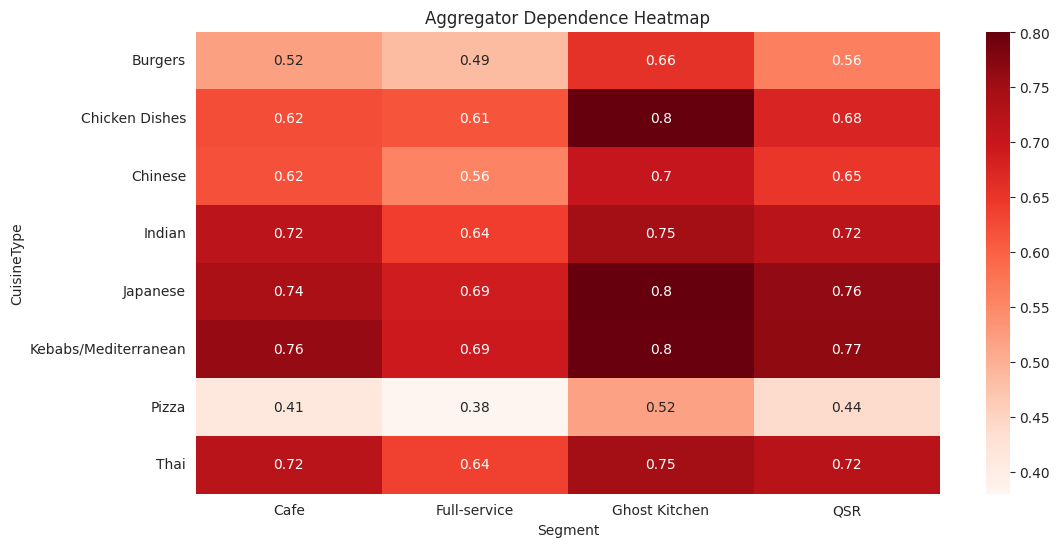

In [76]:
risk_matrix = pd.pivot_table(
    df,
    values='AggregatorDependence',
    index='CuisineType',
    columns='Segment',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    risk_matrix,
    annot=True,
    cmap='Reds'
)

plt.title("Aggregator Dependence Heatmap")

plt.show()

In [77]:
df['ProfitMargin'] = (
    df['TotalNetProfit'] / df['TotalRevenue']
)

In [78]:
df['ProfitMargin'].describe()

,ProfitMargin
count,1696.000000
mean,0.104457
std,0.112116
min,-0.176629
25%,0.010080
50%,0.134985
75%,0.186511
max,0.343075


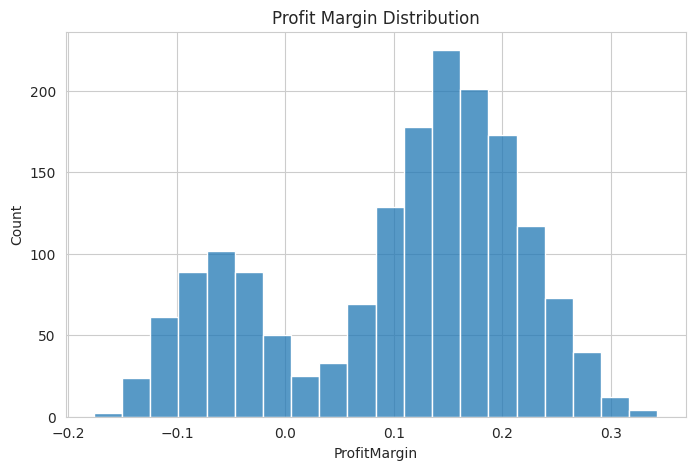

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['ProfitMargin'],
    bins=20
)

plt.title("Profit Margin Distribution")

plt.show()

In [80]:
channel_margin = pd.DataFrame({

    'Channel': [
        'InStore',
        'Uber Eats',
        'DoorDash',
        'Self Delivery'
    ],

    'ProfitMargin': [

        df['InStoreNetProfit'].sum() /
        df['InStoreRevenue'].sum(),

        df['UberEatsNetProfit'].sum() /
        df['UberEatsRevenue'].sum(),

        df['DoorDashNetProfit'].sum() /
        df['DoorDashRevenue'].sum(),

        df['SelfDeliveryNetProfit'].sum() /
        df['SelfDeliveryRevenue'].sum()
    ]
})

channel_margin

,Channel,ProfitMargin
0,InStore,0.268014
1,Uber Eats,0.008388
2,DoorDash,0.009001
3,Self Delivery,0.228925


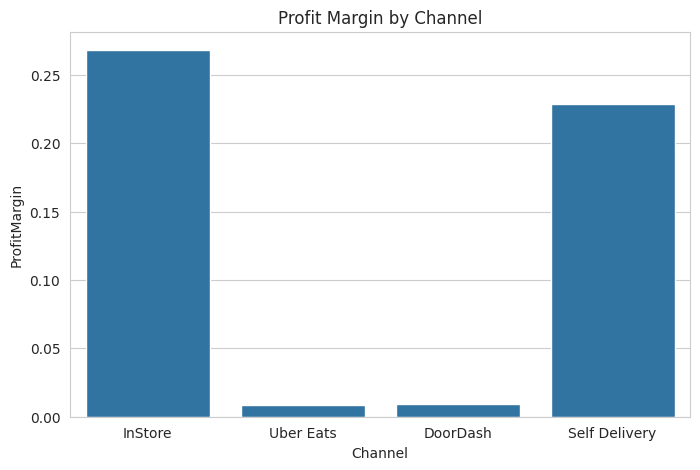

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Channel',
    y='ProfitMargin',
    data=channel_margin
)

plt.title("Profit Margin by Channel")

plt.show()

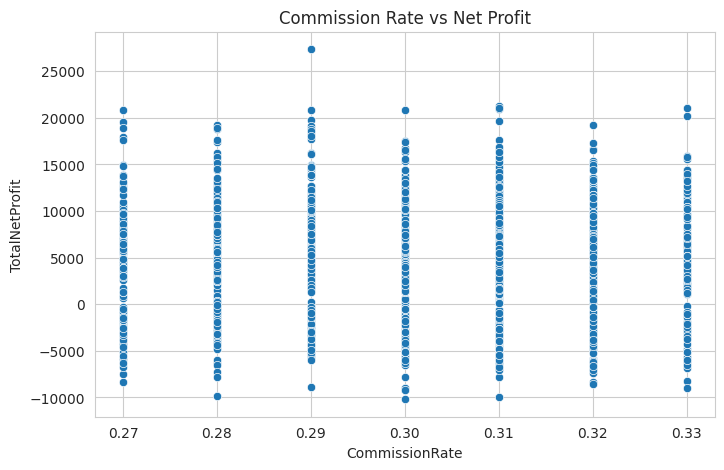

In [82]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='CommissionRate',
    y='TotalNetProfit',
    data=df
)

plt.title("Commission Rate vs Net Profit")

plt.show()

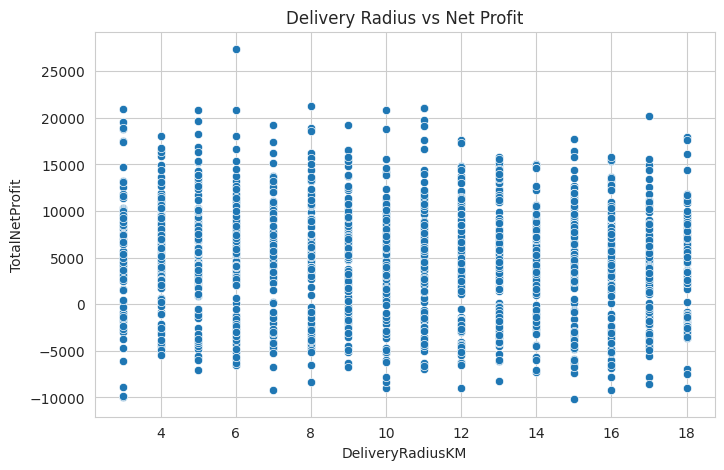

In [83]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='DeliveryRadiusKM',
    y='TotalNetProfit',
    data=df
)

plt.title("Delivery Radius vs Net Profit")

plt.show()

In [84]:
delivery_cost_analysis = df.groupby('Segment')[
    'SD_DeliveryTotalCost'
].mean().reset_index()

delivery_cost_analysis

,Segment,SD_DeliveryTotalCost
0,Cafe,742.589266
1,Full-service,771.848451
2,Ghost Kitchen,800.012944
3,QSR,738.612210


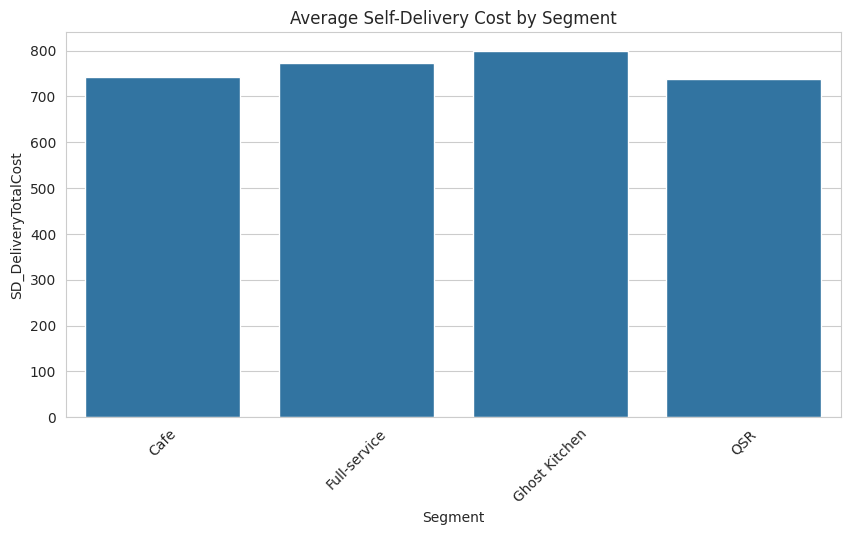

In [85]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Segment',
    y='SD_DeliveryTotalCost',
    data=delivery_cost_analysis
)

plt.title("Average Self-Delivery Cost by Segment")

plt.xticks(rotation=45)

plt.show()

In [86]:
top_profit = df[[
    'RestaurantName',
    'CuisineType',
    'Segment',
    'TotalNetProfit'
]].sort_values(
    by='TotalNetProfit',
    ascending=False
)

top_profit.head(10)

,RestaurantName,CuisineType,Segment,TotalNetProfit
1551,King Pizza Eatery,Pizza,Cafe,27368.36
113,Top Burgers Tavern,Burgers,Cafe,21269.54
1538,Urban Pizza Grill,Pizza,Cafe,21101.73
1567,Lucky Pizza Bistro,Pizza,Cafe,21091.11
1143,Red Cafe,Japanese,Ghost Kitchen,20911.68
79,Top Burgers Eatery,Burgers,Cafe,20842.89
329,Top Burgers Diner,Burgers,Cafe,20828.26
1380,Urban Pizza Tavern,Pizza,Cafe,20827.71
1453,Classic Pizza Eatery,Pizza,QSR,20217.63
722,Golden Bistro,Chinese,Ghost Kitchen,19741.76


In [87]:
least_profit = df[[
    'RestaurantName',
    'CuisineType',
    'Segment',
    'TotalNetProfit'
]].sort_values(
    by='TotalNetProfit'
)

least_profit.head(10)

,RestaurantName,CuisineType,Segment,TotalNetProfit
1244,Ottoman Diner,Kebabs/Mediterranean,Full-service,-10192.83
885,Tandoori Kitchen,Indian,Full-service,-9974.52
1067,Spice Diner,Indian,Full-service,-9840.65
1649,Lotus Tavern,Thai,Full-service,-9224.14
1269,Greek House,Kebabs/Mediterranean,Full-service,-9202.01
1331,Greek Grill,Kebabs/Mediterranean,Full-service,-9024.43
467,Top Chicken Dishes Corner,Chicken Dishes,Full-service,-8962.15
1315,Souvlaki Tavern,Kebabs/Mediterranean,Full-service,-8948.12
830,Bombay House,Indian,Full-service,-8905.84
1284,Ottoman Bistro,Kebabs/Mediterranean,Full-service,-8562.72


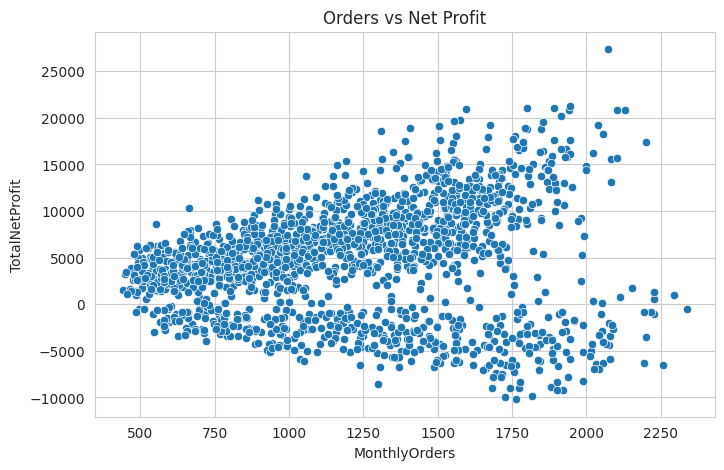

In [88]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='MonthlyOrders',
    y='TotalNetProfit',
    data=df
)

plt.title("Orders vs Net Profit")

plt.show()

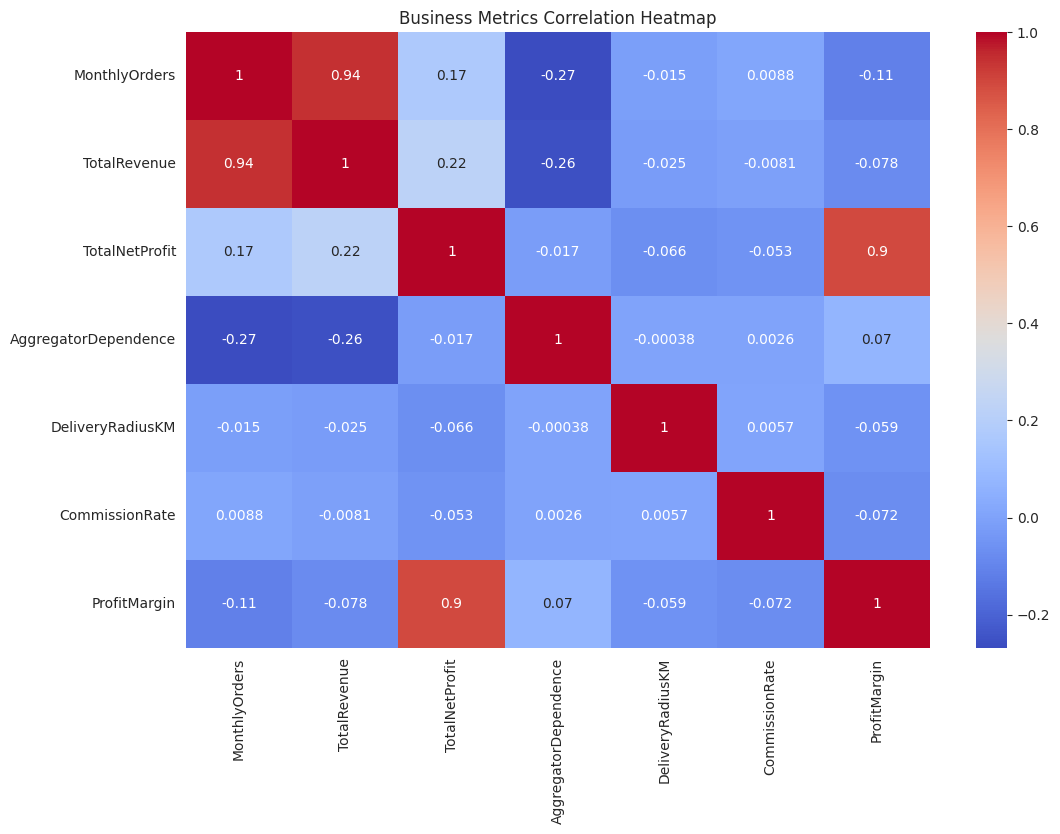

In [89]:
plt.figure(figsize=(12,8))

corr = df[[
    'MonthlyOrders',
    'TotalRevenue',
    'TotalNetProfit',
    'AggregatorDependence',
    'DeliveryRadiusKM',
    'CommissionRate',
    'ProfitMargin'
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Business Metrics Correlation Heatmap")

plt.show()